\definecolor{uomaccent}{HTML}{55499C}

\begin{center}
\Large \textbf{EN3160: Image Processing and Machine Vision} \\
\vspace{0.2cm}
{\Large \textbf{\color{uomaccent} Assignment 1: Intensity Transformations and Neighborhood Filtering}} \\
\vspace{0.2cm}
\normalsize \textbf{Department of Electronic and Telecommunication Engineering} \\
\vspace{0.2cm}
\normalsize \textbf{University of Moratuwa}\\
\vspace{0.2cm}
\normalsize \textbf{September 14, 2026}
\end{center}

\vspace{0.4cm}

\noindent\textbf{Name:} Samarasinghe S.M.R.R. \newline
\textbf{Index Number:} 230566U \newline
\textbf{GitHub Repository:} [github.com/RumethRanhinda/EN3160-Vision-UoM](https://github.com/RumethRanhinda/EN3160-Vision-UoM/tree/main/Assignments/Intensity%20Transformations%20and%20Spatial%20Filtering)

\noindent\rule{\textwidth}{0.5pt}

\vspace{0.4cm}

\noindent\textbf{1. Intensity Transformation Implementation}

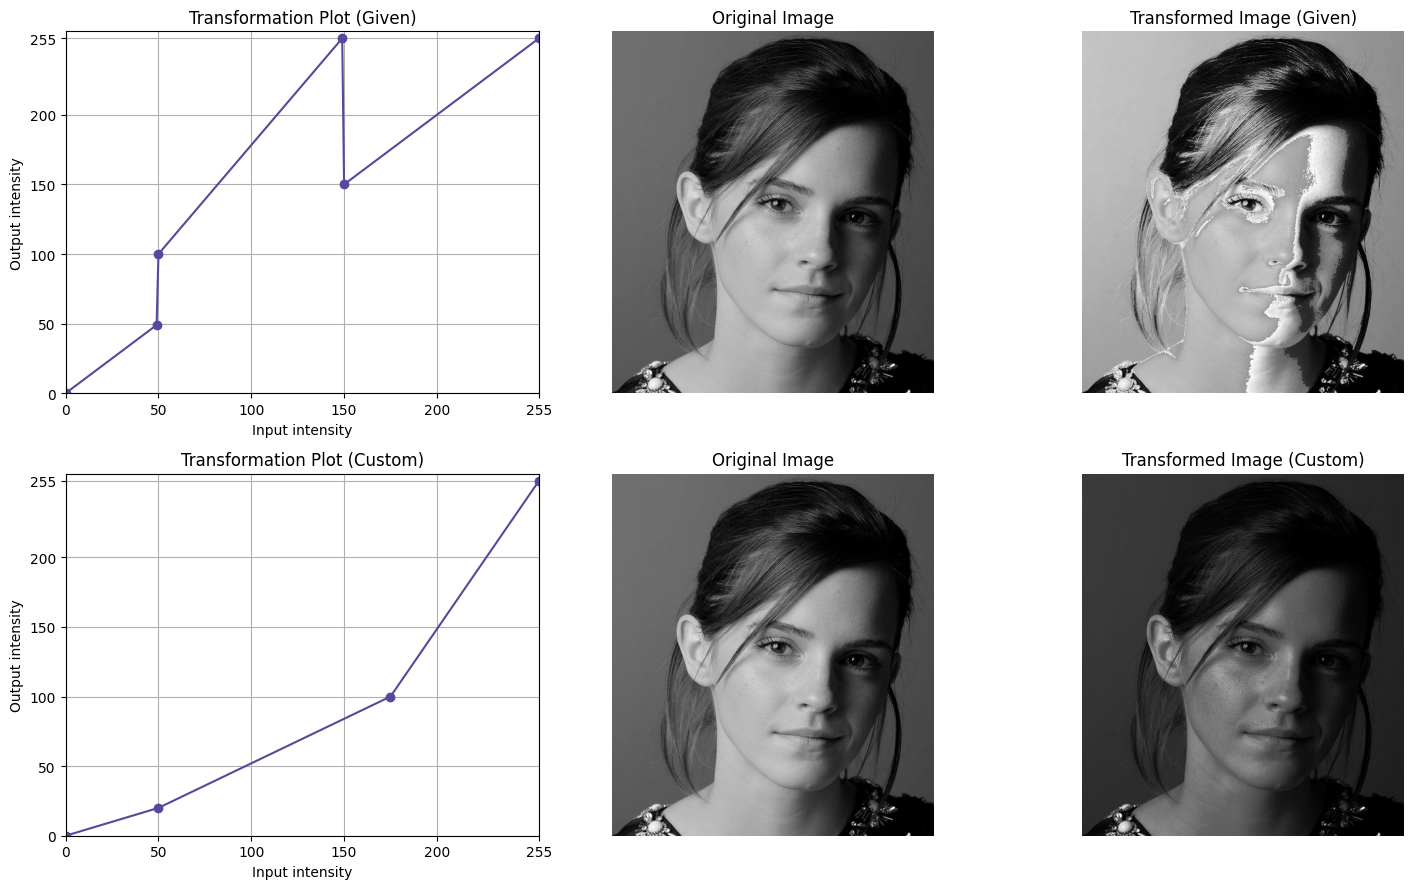

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    bp = np.array(breakpoints)
    xp = bp[:, 0]  # Input intensities
    yp = bp[:, 1]  # Output intensities
    
    # Apply interpolation and reshape back to original image dimensions
    transformed_im = np.interp(im.flatten(), xp, yp).reshape(im.shape)
    
    return transformed_im.astype(np.uint8)

img = cv2.imread('Images/emma.jpeg', cv2.IMREAD_GRAYSCALE)

if img is not None:
    # Provided breakpoints 
    bp_given = [[0, 0], [49, 49], [50, 100], [149, 255], [150, 150], [255, 255]]
    
    # Custom breakpoints
    bp_custom = [[0, 0], [50, 20], [175, 100], [255, 255]]
    
    transformed_given = intensity_transform(img, bp_given)
    transformed_custom = intensity_transform(img, bp_custom)

    # Define grid ticks for the plots
    grid_ticks = [0, 50, 100, 150, 200, 255]

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    
    # Given Breakpoints
    bp_given_arr = np.array(bp_given)
    axes[0, 0].plot(bp_given_arr[:,0], bp_given_arr[:,1], marker='o', color='#55499C')
    axes[0, 0].set_title("Transformation Plot (Given)")
    axes[0, 0].set_xlabel("Input intensity"); axes[0, 0].set_ylabel("Output intensity")
    axes[0, 0].set_xlim([0, 255]); axes[0, 0].set_ylim([0, 260])
    
    # Apply custom grid
    axes[0, 0].set_xticks(grid_ticks)
    axes[0, 0].set_yticks(grid_ticks)
    axes[0, 0].grid(True)
    
    axes[0, 1].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[0, 1].set_title("Original Image")
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(transformed_given, cmap='gray', vmin=0, vmax=255)
    axes[0, 2].set_title("Transformed Image (Given)")
    axes[0, 2].axis('off')

    # Custom Breakpoints
    bp_custom_arr = np.array(bp_custom)
    axes[1, 0].plot(bp_custom_arr[:,0], bp_custom_arr[:,1], marker='o', color='#55499C')
    axes[1, 0].set_title("Transformation Plot (Custom)")
    axes[1, 0].set_xlabel("Input intensity"); axes[1, 0].set_ylabel("Output intensity")
    axes[1, 0].set_xlim([0, 255]); axes[1, 0].set_ylim([0, 260])
    
    axes[1, 0].set_xticks(grid_ticks)
    axes[1, 0].set_yticks(grid_ticks)
    axes[1, 0].grid(True)
    
    axes[1, 1].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[1, 1].set_title("Original Image")
    axes[1, 1].axis('off')
    
    axes[1, 2].imshow(transformed_custom, cmap='gray', vmin=0, vmax=255)
    axes[1, 2].set_title("Transformed Image (Custom)")
    axes[1, 2].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Image not found")

The given intensity transformation made high intensities darker in a discontinous way which explains the artifact seen in the output image.

The custom transformation intended to highlight the freckles in the face by providing a wider range for brigther pixels.

\vspace{0.5cm}

\noindent\textbf{\color{uomaccent} 2. Accentuate White and Gray Matter}

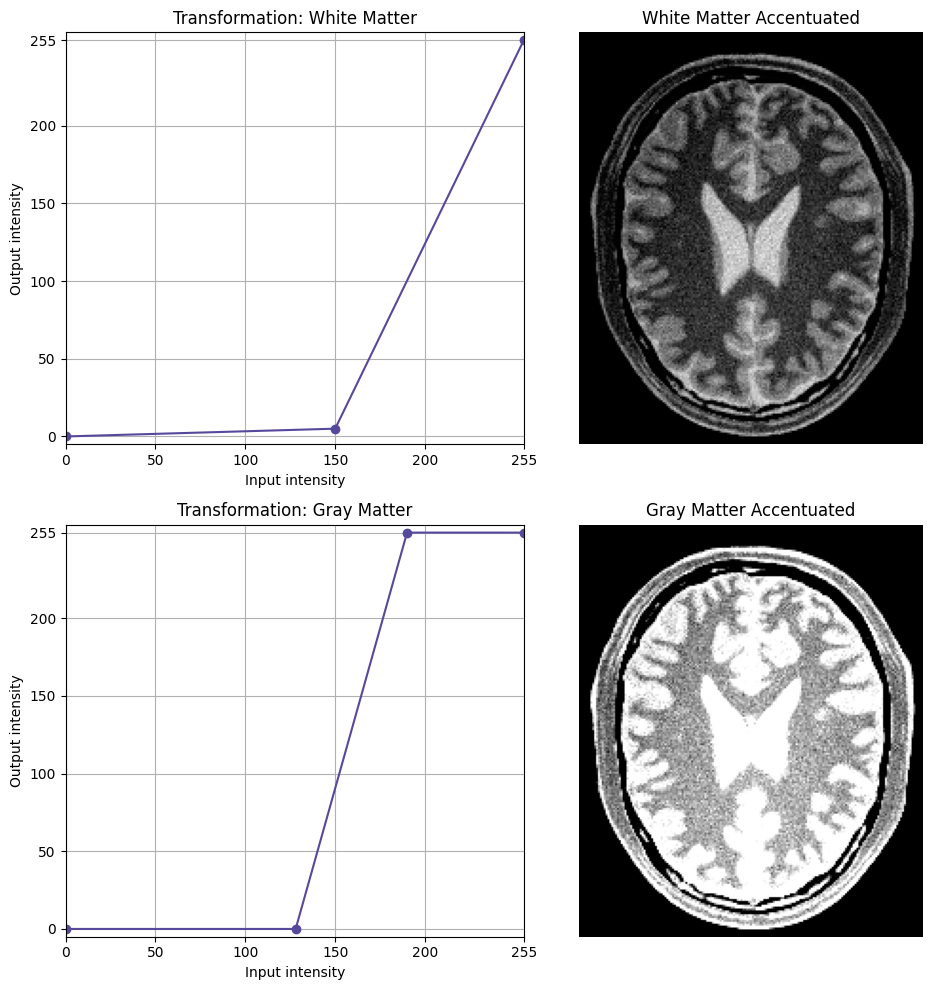

In [49]:
brain_img = cv2.imread('Images/brain.jpeg', cv2.IMREAD_GRAYSCALE)

if brain_img is not None:
    bp_white_matter = [[0, 0], [150, 5], [255, 255]]
    bp_gray_matter = [[0, 0], [128, 0], [190, 255], [255, 255]]
    wm_accentuated = intensity_transform(brain_img, bp_white_matter)
    gm_accentuated = intensity_transform(brain_img, bp_gray_matter)
    grid_ticks = [0, 50, 100, 150, 200, 255]
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    
    # White Matter Transformation
    bp_wm_arr = np.array(bp_white_matter)
    axes[0, 0].plot(bp_wm_arr[:,0], bp_wm_arr[:,1], marker='o', color='#55499C')
    axes[0, 0].set_title("Transformation: White Matter")
    axes[0, 0].set_xlabel("Input intensity") ;axes[0, 0].set_ylabel("Output intensity")
    axes[0, 0].set_xlim([0, 255]); axes[0, 0].set_ylim([-5, 260])
    axes[0, 0].set_xticks(grid_ticks); axes[0, 0].set_yticks(grid_ticks); axes[0, 0].grid(True)
    axes[0, 1].imshow(wm_accentuated, cmap='gray', vmin=0, vmax=255)
    axes[0, 1].set_title("White Matter Accentuated"); axes[0, 1].axis('off')

    # Gray Matter Transformation
    bp_gm_arr = np.array(bp_gray_matter)
    axes[1, 0].plot(bp_gm_arr[:,0], bp_gm_arr[:,1], marker='o', color='#55499C')
    axes[1, 0].set_title("Transformation: Gray Matter"); axes[1, 0].set_xlabel("Input intensity")
    axes[1, 0].set_ylabel("Output intensity"); axes[1, 0].set_xlim([0, 255]); axes[1, 0].set_ylim([-5, 260])
    axes[1, 0].set_xticks(grid_ticks); axes[1, 0].set_yticks(grid_ticks); axes[1, 0].grid(True)
    axes[1, 1].imshow(gm_accentuated, cmap='gray', vmin=0, vmax=255)
    axes[1, 1].set_title("Gray Matter Accentuated"); axes[1, 1].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Image not found")